# Day 7: Session 7B - Name the Columns, Not the Colours

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7b_seaborn.html)

Date: 09/09/2026

### **seaborn** (https://seaborn.pydata.org/) takes a dataframe including the names of the columns you want plotted, and does the drawing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/messy_field_survey.csv'
survey = pd.read_csv(url)

survey = survey.drop_duplicates()

survey['site'] = survey['site'].str.strip()
survey['site'] = survey['site'].str.lower()
survey['site'] = survey['site'].str.replace('-', '_')

survey['pH'] = survey['pH'].str.replace(',', '.')
survey['pH'] = survey['pH'].astype(float)

survey = survey.dropna(subset=['temperature_c', 'dissolved_oxygen_mg_L', 'conductivity_uS_cm'])
survey['n_replicates'] = survey['n_replicates'].fillna(1)
survey['n_replicates'] = survey['n_replicates'].astype(int)

survey = survey[survey['temperature_c'] > -100].copy()
survey = survey.rename(columns={'collection date': 'collection_date'})

survey.shape

(255, 7)

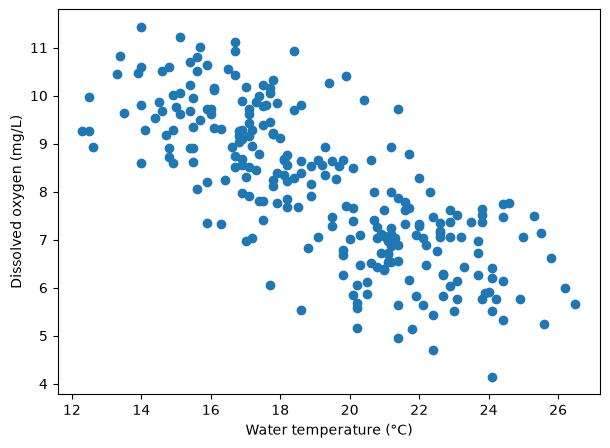

In [2]:
plt.figure(figsize=(7, 5))

plt.scatter(survey['temperature_c'], survey['dissolved_oxygen_mg_L'])

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.show()

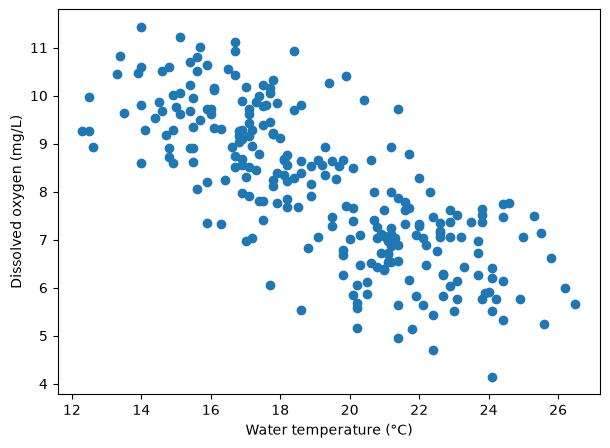

In [3]:
plt.figure(figsize=(7, 5))

plt.scatter(survey['temperature_c'], survey['dissolved_oxygen_mg_L'])

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.show()

### write the three seaborn calls this course uses: sns.scatterplot, sns.histplot and sns.barplot


In [ ]:
# sns.scatterplot(data=df, x='column_name', y='column_name')
# #               ↑        ↑                ↑
# #               the      which column     which column
# #               table    across           up

data= takes the whole table, once.

x= and y= take column names as strings, not the columns themselves.

The axes came out labelled, because the column names went in with the table.

### hue= takes a column name and gives every distinct value in that column its own colour, with a legend built for free.

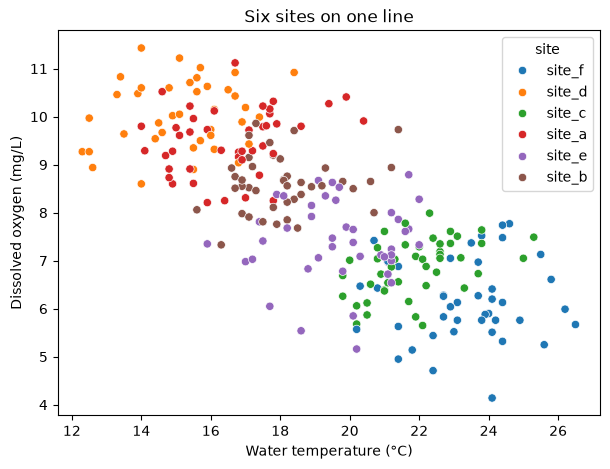

In [4]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=survey,
     x='temperature_c',
      y='dissolved_oxygen_mg_L',
       hue='site')

plt.xlabel('Water temperature (°C)')
plt.ylabel('Dissolved oxygen (mg/L)')
plt.title('Six sites on one line')
plt.show()

#### sns.histplot: the shape of one column
A scatter needs two variables. When you have one variable and want to know how its values are distributed, you want a histogram: the values sorted into bins, with a bar showing how many values are in each bin.

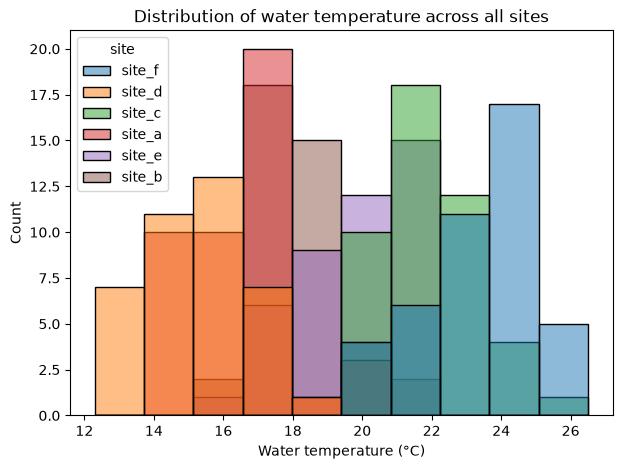

In [6]:
plt.figure(figsize=(7, 5))

sns.histplot(data=survey, x='temperature_c', hue='site')

plt.xlabel('Water temperature (°C)')
plt.title('Distribution of water temperature across all sites')
plt.show()

data= and x=, and no y=, because the height of each bar is a count that seaborn computes for you.

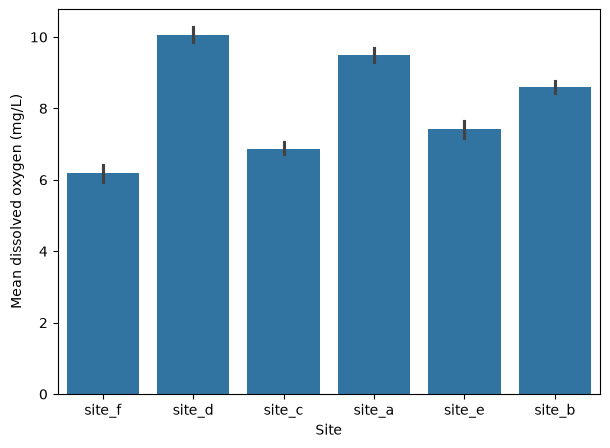

In [7]:
plt.figure(figsize=(7, 5))

sns.barplot(data=survey, x='site', y='dissolved_oxygen_mg_L')

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.show()

The little black line on each bar is a measure of how uncertain that mean is, computed by resampling the data hundreds of times. The alternative is to compute the number yourself, with the split-apply-combine pattern, and hand seaborn the answer...

### feed a grouped Series to sns.barplot using its .values and its .index


In [ ]:
# sns.barplot(x=series.values, y=series.index)   
# # horizontal bars, sorted as you sorted them
# sns.barplot(y=series.values, x=series.index)   
# # vertical bars, same data

In [ ]:
# manual calc of means
# group, aggregate, sort

mean_do = survey.groupby('site')['dissolved_oxygen_mg_L'].mean().sort_values(ascending=False)

mean_do.round(2)

site
site_d    10.05
site_a     9.49
site_b     8.60
site_e     7.41
site_c     6.87
site_f     6.18
Name: dissolved_oxygen_mg_L, dtype: float64

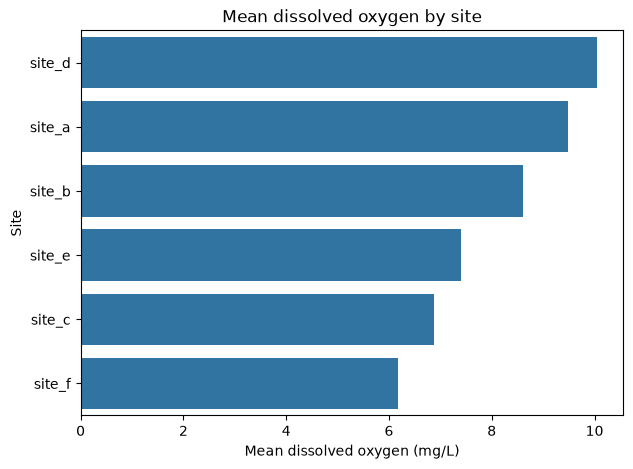

In [ ]:
# group, aggregate, sort (above),
# then plot the .values against the .index.

plt.figure(figsize=(7, 5))

sns.barplot(x=mean_do.values, y=mean_do.index)

plt.xlabel('Mean dissolved oxygen (mg/L)')
plt.ylabel('Site')
plt.title('Mean dissolved oxygen by site')
plt.show()

### seaborn draws onto a matplotlib axes. If none exists it makes one, exactly the way plt.plot() does. 

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(x=mean_do.index, y=mean_do.values)

plt.xlabel('Site')
plt.ylabel('Mean dissolved oxygen (mg/L)')
plt.title('Mean dissolved oxygen by site, 2025 field season')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **seaborn** draws the marks and places them, 
# and matplotlib provides the frame around them
# When you want to change something about the data, 
# change a seaborn argument. 
# When you want to change something about the figure, 
# use plt.

### Key points
A seaborn call looks like sns.function(data=df, x='col', y='col'). The table goes in whole and the columns are named as strings.

hue='col' splits any of these plots by a categorical column and builds the legend for you. It is the argument that answers does this relationship differ between groups?

sns.scatterplot for one measurement against another.

sns.histplot(data=, x=) for the distribution of a single column. No y=; the heights are counts.

sns.barplot(data=, x='category', y='value') silently computes a mean and draws an uncertainty interval you did not ask for.

Prefer the explicit route: .groupby(), aggregate, .sort_values(), then sns.barplot(x=series.values, y=series.index). You control the number and the order.

seaborn draws on matplotlib, so plt.figure(figsize=), plt.xlabel(), plt.title(), plt.xticks(rotation=) and plt.tight_layout() all still work.

A distribution that mixes groups looks wider than any group in it. Split it before you describe it.